# 01 - Analisis del dataset

Objetivo: revisar cantidad de imagenes por clase y por particion.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATASET_DIR = PROJECT_ROOT / 'datasets'
classes = ['no_yawn', 'yawn']
splits = ['train', 'validation', 'test']

In [2]:
rows = []
for split in splits:
    for class_name in classes:
        folder = DATASET_DIR / split / class_name
        count = len([p for p in folder.rglob('*') if p.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}]) if folder.exists() else 0
        rows.append({'split': split, 'class': class_name, 'count': count})

df = pd.DataFrame(rows)
df

,split,class,count
0,train,no_yawn,81
1,train,yawn,67
2,validation,no_yawn,17
3,validation,yawn,14
4,test,no_yawn,18
5,test,yawn,16


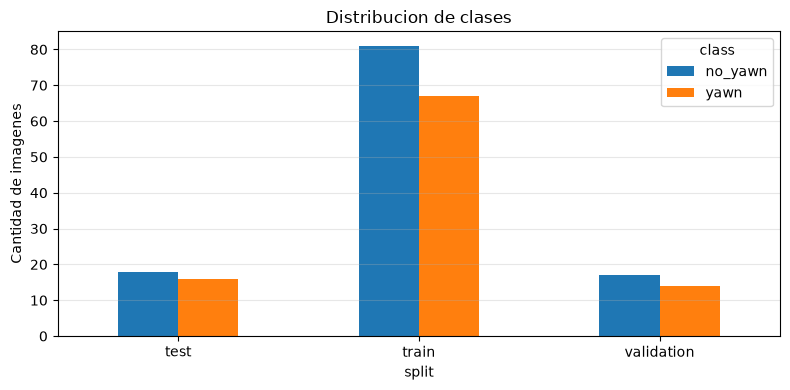

In [3]:
pivot = df.pivot(index='split', columns='class', values='count')
pivot.plot(kind='bar', figsize=(8, 4), title='Distribucion de clases')
plt.ylabel('Cantidad de imagenes')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()